# Visualisation of the result 

In [7]:
import Pkg
Pkg.build()

Precompiling project...
  19381.2 ms  ✓ LightXML
XSLT_jll Waiting for background task / IO / timer.
[pid 355728] waiting for IO to finish:
 Handle type        uv_handle_t->data
 fs_event           0x2d2f1720->0x7f686247d630
 timer              0x2d394bd0->0x7f686247d660
This means that a package has started a background task or event source that has not finished running. For precompilation to complete successfully, the event source needs to be closed explicitly. See the developer documentation on fixing precompilation hangs for more help.
  34023.6 ms  ✓ XSLT_jll
  40357.0 ms  ✓ MarchingCubes
  36202.7 ms  ✓ MIToS
  69342.0 ms  ✓ Clustering
  77371.5 ms  ✓ Interpolations → InterpolationsUnitfulExt
  89687.2 ms  ✓ Distributions
  32413.0 ms  ✓ MIToS → MIToSClusteringExt
  28944.7 ms  ✓ Distributions → DistributionsTestExt
  28806.3 ms  ✓ Distributions → DistributionsChainRulesCoreExt
  37344.0 ms  ✓ MultivariateStats
 108528.4 ms  ✓ Qt6ShaderTools_jll
  19382.8 ms  ✓ Qt6Declarative_jll


In [2]:
using DataFrames
import CSV
#Importation des données
file_path_df_final="pdb_information_details.csv"
df=DataFrames.DataFrame(CSV.File(file_path_df_final,
comment="#", missingstring=["", "None"])) # Output DF with PDB CHAIN RESOLUTION SITE LIGAND
println(first(df,20))
println(size(df))

20×11 DataFrame
 Row │ PDB      CHAIN    RES_BEG  RES_END  PFAM_NB  CATH_NB  RESOLUTION  METHOD    DATE_RELEASE  UNIPROT     LIGANDS  
     │ String7  String7  Int64?   Int64?   Int64    Int64    Float64?    String31  Date          String15    String?  
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ 6kv9     A              7      346        1        0        1.48  X-ray     2019-11-13    A0A003      NAD, UGA
   2 │ 6kvc     A              7      346        1        0        1.66  X-ray     2019-11-13    A0A003      NAD, UPG
   3 │ 7m4y     R              1      109        1        0        2.5   EM        2021-05-19    A0A009I821  rna
   4 │ 7m4z     R              1      109        1        0        2.92  EM        2021-05-19    A0A009I821  rna
   5 │ 7ryf     R              1      109        1        0        2.65  EM        2022-02-02    A0A009I821  rna
   6 │ 7ryg     R              1      109        1  

## Analyse global

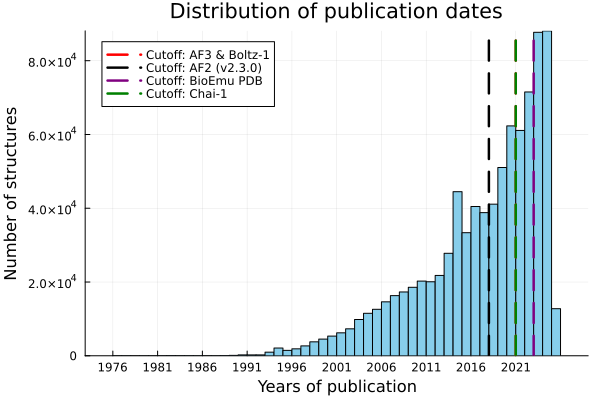

In [5]:
using Plots, Dates

# Crée l'histogramme avec une barre par année
years = year.(df.DATE_RELEASE)
all_years = minimum(years):maximum(years)  # toutes les années

hist = histogram(
    years,
    bins=length(all_years),  # 1 barre par an
    xticks=(collect(all_years[1:5:end]), string.(all_years[1:5:end])),  # afficher 1 an sur 5
    color=:skyblue,
    edgecolor=:black,
    title="Distribution of publication dates",
    xlabel="Years of publication",
    ylabel="Number of structures",
    legend=:topleft,
    label=""
)

# Dates de cutoff avec couleurs personnalisées
cutoffs = [
    ("AF3 & Boltz-1", Date("2021-09-30"), :red),
    ("AF2 (v2.3.0)", Date("2018-04-30"), :black),
    ("BioEmu PDB", Date("2023-11-23"), :purple),
    ("Chai-1", Date("2021-01-12"), :green)
]

# Ajoute les lignes verticales
for (label, date, color) in cutoffs
    vline!(
        hist,
        [year(date)],
        label="Cutoff: $label",
        color=color,
        linewidth=2.5,
        linestyle=:dash
    )
end

# Affiche le plot
display(hist)


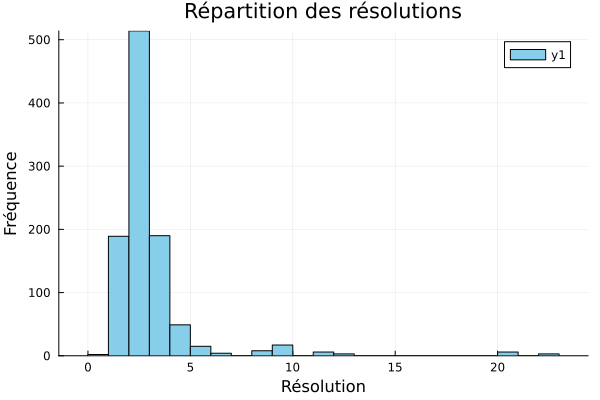

In [13]:
#Voir dispersion des résolutions
histogram(df.RESOLUTION, 
    title="Répartition des résolutions", 
    xlabel="Résolution", ylabel="Fréquence", 
    bins=20, color=:skyblue, edgecolor=:black)


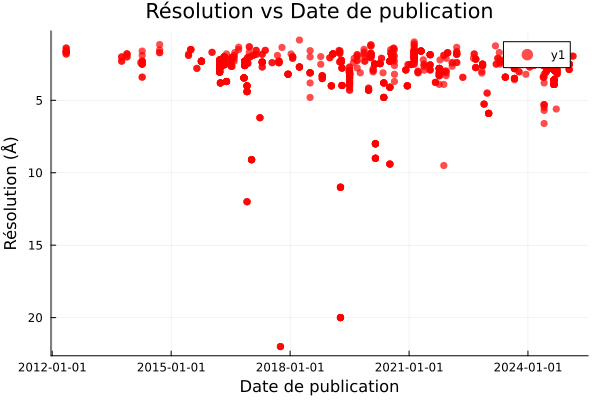

In [14]:
#Voir si lien entre resolutions et date de publication
scatter(df.DATE_RELEASE, df.RESOLUTION, color=:red, alpha=0.7, markerstrokewidth=0, 
    title="Résolution vs Date de publication", xlabel="Date de publication", ylabel="Résolution (Å)")
yflip!()  # En cristallographie, une valeur plus basse est meilleure

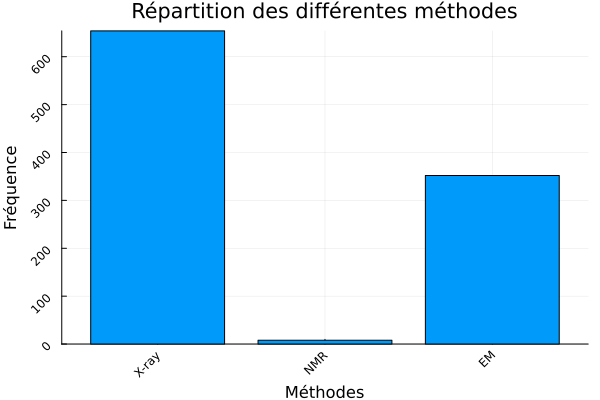

In [71]:
#Voir la répartition entre les differentes méthodes
using StatsBase
# Compter la fréquence des différentes méthodes
method_counts = countmap(df.METHOD)

# Extraire les labels (méthodes) et les fréquences
methods = collect(keys(method_counts))  # Liste des méthodes
frequencies = collect(values(method_counts))  # Nombre d'occurrences

# Faire un barplot (adapté aux données catégorielles)
bar(methods, frequencies, 
    title="Répartition des différentes méthodes", 
    xlabel="Méthodes", ylabel="Fréquence", 
    legend=false, rotation=45)


In [72]:
for i in 1:length(methods)
    percentage = (frequencies[i] / total) * 100
    println(percentage)
end

64.49704142011834
0.7889546351084813
34.714003944773175


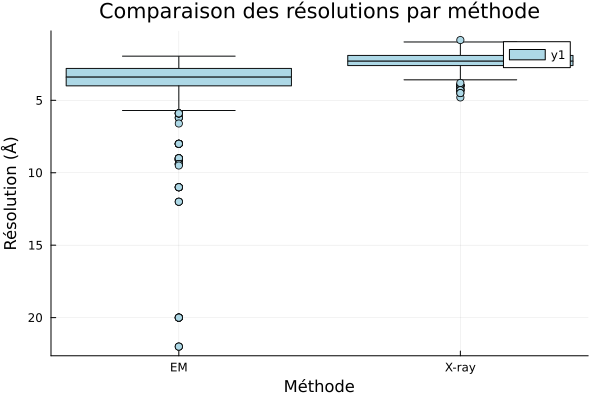

In [17]:
#Voir lien entre le méthode et la résolution 
# Filtrer les données pour exclure la méthode "NMR"
df_xray = filter(row -> row.METHOD != "NMR", df)

# Boxplot de la résolution en fonction de la méthode utilisée
@df df_xray boxplot(:METHOD, :RESOLUTION, color=:lightblue, outlier=:circle, 
    title="Comparaison des résolutions par méthode", xlabel="Méthode", ylabel="Résolution (Å)")
yflip!()  # Valeurs plus basses = meilleure résolution

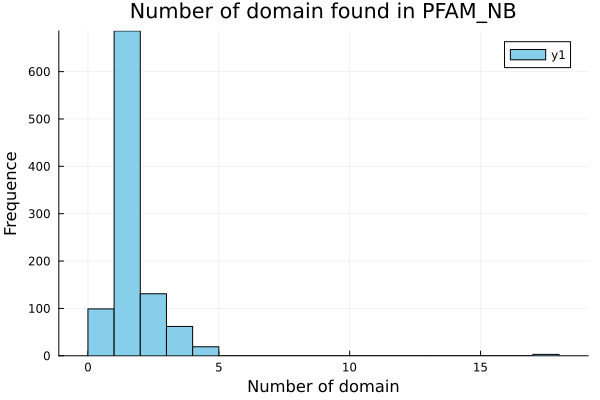

In [5]:
#Voir dispersion du nombes de domaine dans 
using StatsBase
histogram(df.PFAM_NB, 
title="Number of domain found in PFAM_NB", 
xlabel="Number of domain", ylabel="Frequence", 
bins=20, color=:skyblue, edgecolor=:black)

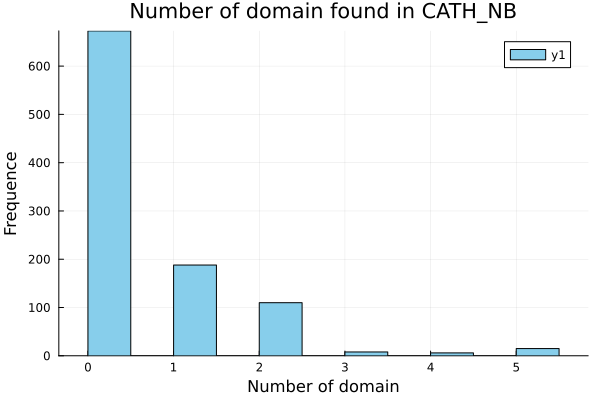

In [6]:
#Voir dispersion du nombes de domaine dans CATH_NB
histogram(df.CATH_NB, 
title="Number of domain found in CATH_NB", 
xlabel="Number of domain", ylabel="Frequence", 
bins=20, color=:skyblue, edgecolor=:black)

In [8]:
#Voir dispersion du nombre de mutation
histogram(df.MUTATION, 
title="Number of mutation", 
xlabel="Number of mutation", ylabel="Frequence", 
bins=20, color=:skyblue, edgecolor=:black)


ArgumentError: ArgumentError: column name :MUTATION not found in the data frame

In [7]:
#Voir dispersion du nombre de residues manquant
histogram(df.MISSING_RESIDUES, 
title="Number of missing residues", 
xlabel="Number of mising residues", ylabel="Fréquence", 
bins=20, color=:skyblue, edgecolor=:black)


ArgumentError: ArgumentError: column name :MISSING_RESIDUES not found in the data frame

## Analyse en fonction des formes APO et HOLO

In [35]:
#Regroupe les pdb en fonction form apo et holo
df.is_apo = ismissing.(df.LIGANDS)  # Ajoute une colonne booléenne is_apo
df_grouped = combine(groupby(df, :is_apo),
    nrow => :Count,
    :RESOLUTION => mean => :Mean_Resolution,
    :PFAM_NB => mean => :Mean_PFAM,
    :CATH_NB => mean => :Mean_CATH,
    :MUTATION => mean => :Mean_MUTATION,
    :MISSING_RESIDUES => mean => :Mean_MISSING_RESSIDUES
)
println(first(df_grouped,20))

2×7 DataFrame
 Row │ is_apo  Count  Mean_Resolution  Mean_PFAM  Mean_CATH  Mean_MUTATION  Mean_MISSING_RESSIDUES 
     │ Bool    Int64  Missing          Float64    Float64    Float64        Float64                
─────┼─────────────────────────────────────────────────────────────────────────────────────────────
   1 │  false    407          missing    1.2113    0.665848       0.228501                13.5946
   2 │   true    607          missing    1.29489   0.438221       0.466227                 4.94234


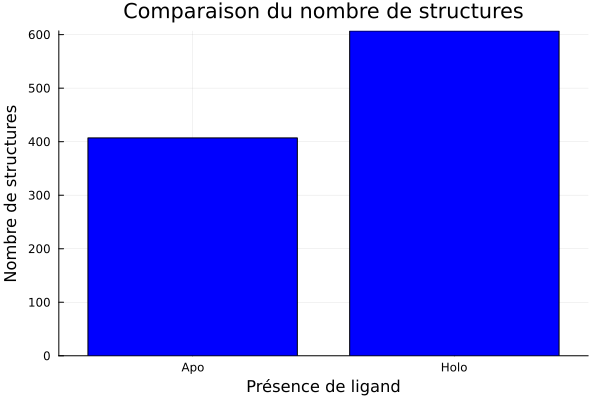

In [36]:
# Barplot pour comparer le nombre de structures
@df df_grouped bar(:is_apo, :Count, legend=false, color=[:blue :red], 
    title="Comparaison du nombre de structures", xlabel="Présence de ligand", ylabel="Nombre de structures", xticks=([0,1], ["Apo", "Holo"]))


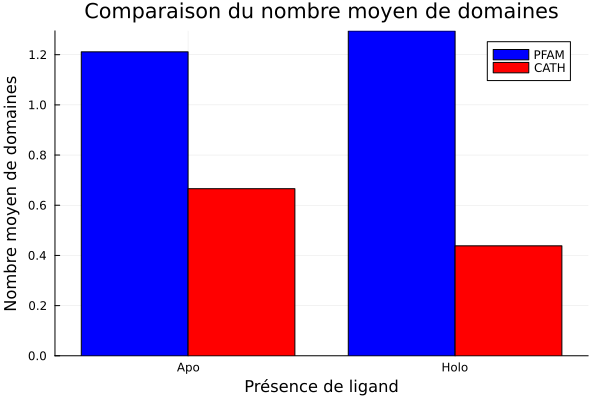

In [40]:
# Barplot pour comparer les annotations PFAM et CATH
@df df_grouped groupedbar(["Apo", "Holo"], [df_grouped.Mean_PFAM df_grouped.Mean_CATH], 
    bar_position=:dodge, color=[:blue :red], 
    title="Comparaison du nombre moyen de domaines", xlabel="Présence de ligand", ylabel="Nombre moyen de domaines", 
    label=["PFAM" "CATH"])

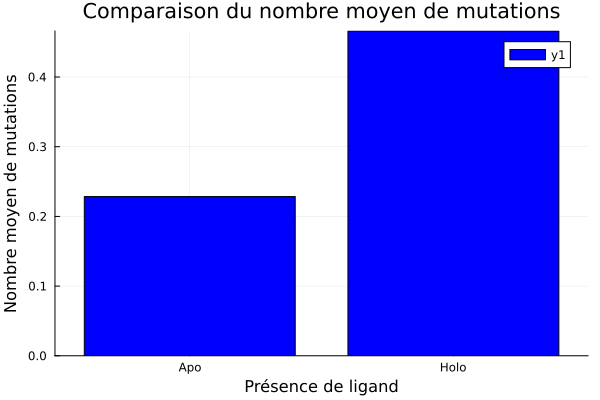

In [52]:
# Barplot pour comparer les annotations PFAM et CATH
@df df_grouped bar(:is_apo, :Mean_MUTATION, color=[:blue :red], 
    title="Comparaison du nombre moyen de mutations", xlabel="Présence de ligand", ylabel="Nombre moyen de mutations",
    xticks=([0,1], ["Apo", "Holo"]), legend=:topright)


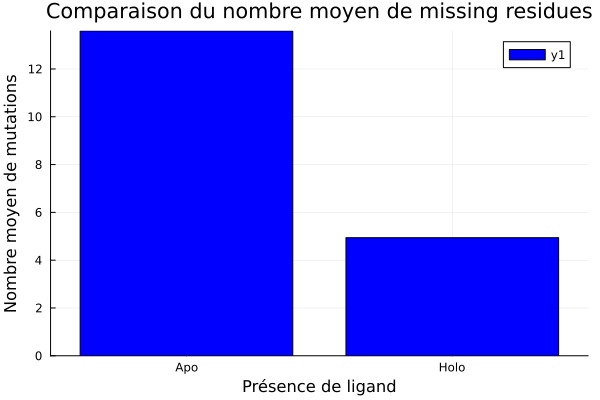

In [54]:
# Barplot pour comparer le nombre de missing residues
@df df_grouped bar(:is_apo, :Mean_MISSING_RESSIDUES, color=[:blue :red], 
    title="Comparaison du nombre moyen de missing residues", xlabel="Présence de ligand", ylabel="Nombre moyen de mutations",
    xticks=([0,1], ["Apo", "Holo"]), legend=:topright)


## Analyse des clusters

In [ ]:

function check_apo_holo_cluster(df_completed::DataFrame)
    check_cluster=DataFrame(UNIPROT=String[],HOLO_APO=Bool[],BEST_CUTOFF=Union{Float64,Missing}[]) # Create an empty DF

    for row in eachrow(df_completed)
        uniprot=row.UNIPROT # Check for every uniprot accession 
        #Check that we haven't already done this
        is_present= uniprot in check_cluster.UNIPROT
        if !is_present
            df_uniprot = select(filter(row -> row.UNIPROT == uniprot, df_completed), ["PDB", "LIGANDS", "Cluster_1.5", "Cluster_2.0","Cluster_4.0"])# To focus on the uniprot 
            
            #Look if we have both conformation for this uniprot
            is_apo = any(ismissing, df_uniprot.LIGANDS)
            if is_apo 
                # Filter files with and without ligands
                with_ligands = filter(row -> !ismissing(row.LIGANDS), df_uniprot)
                without_ligands = filter(row -> ismissing(row.LIGANDS), df_uniprot)
                result = 9
                # Compare clusters for each cutoff
                for cutoff in [1.5, 2.0, 4.0]
                    # Retrieve clusters for each cutoff
                    cluster_col = Symbol("Cluster_$(cutoff)")

                    # Compare files without ligands and with ligands
                    for file_with_ligands in eachrow(with_ligands)
                        for file_without_ligands in eachrow(without_ligands)
                            if !ismissing(file_with_ligands[cluster_col]) && 
                                !ismissing(file_without_ligands[cluster_col]) && 
                                file_with_ligands[cluster_col] != file_without_ligands[cluster_col]
                                # If the files are in different clusters, take the smaller value
                                if  cutoff<result
                                    result = cutoff
                                end
                            end
                        end
                    end
                end
                push!(check_cluster,(uniprot,true,result))
                
            else 
                push!(check_cluster,(uniprot,false,missing))
            end 
        end
    end
    return check_cluster #Output the result 
end
check_cluster=check_apo_holo_cluster(df)
println(first(check_cluster,20))
most_frequent_value = mode(check_cluster.BEST_CUTOFF)
println("The cutoff that best separates the apo and holo form is : ", most_frequent_value)
frequency = count(x -> !ismissing(x) && x == most_frequent_value, check_cluster.BEST_CUTOFF)
println("She appears ", frequency, " time.")
println(size(check_cluster))
println("It separates properly : ",(frequency/size(check_cluster)[1])*100)

20×3 DataFrame
 Row │ UNIPROT     HOLO_APO  BEST_CUTOFF 
     │ String      Bool      Float64?    
─────┼───────────────────────────────────
   1 │ A0A023GUP0      true          1.5
   2 │ A0A011         false    missing   
   3 │ A0A023GPI8     false    missing   
   4 │ A0A024E3Q2     false    missing   
   5 │ A0A024SC78      true          1.5
   6 │ A0A023T3X2     false    missing   
   7 │ A0A024UZE1      true          9.0
   8 │ A0A024V0B1     false    missing   
   9 │ A0A010          true          9.0
  10 │ A0A023GUL3      true          9.0
  11 │ A0A023H437     false    missing   
  12 │ A0A024B7W1      true          9.0
  13 │ A0A024QYS6      true          9.0
  14 │ A0A023R6W2      true          1.5
  15 │ A0A023PKG5      true          9.0
  16 │ A0A024FRL9     false    missing   
  17 │ A0A023I7E1      true          9.0
  18 │ A0A034W4L8     false    missing   
  19 │ A0A017T5A5     false    missing   
  20 │ A0A024S820     false    missing   
The cutoff that best separate

"pdb_apo_holo_1000.csv"

# Foldseek result 

In [2]:
using DataFrames
import CSV
#Importation des données
file_path_df_final="pdb_information_details_final_mutation_cluster_reformatted_filter_foldseek2.csv"
df=DataFrames.DataFrame(CSV.File(file_path_df_final,
comment="#", missingstring=["", "None"])) # Output DF with PDB CHAIN RESOLUTION SITE LIGAND
println(first(df,20))
println(size(df))

20×18 DataFrame
 Row │ UNIPROT     PDB      CHAIN    NB_SIMILAR_PROT  RES_BEG  RES_END  PFAM_NB  CATH_NB  RESOLUTION  METHOD    DATE_RELEASE  LIGANDS  Cluster_0.5  Cluster_0.75  Cluster_1.0  Cluster_1.25  Cluster_1.5  Cluster_2.0 
     │ String15    String7  String1  Int64            Int64?   Int64?   Int64    Int64    Float64?    String31  Dates.Date    String?  Int64        Int64         Int64        Int64         Int64        Int64       
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ A0A009IHW8  7uxu     A                    406        4      137        1        0       2.74   EM        2022-09-07    1O4                1             1            1             1            1            1
   2 │ A0A009IHW8  7uxu     B                    406        4      137        1        0       2.74   EM        2022-09-07   

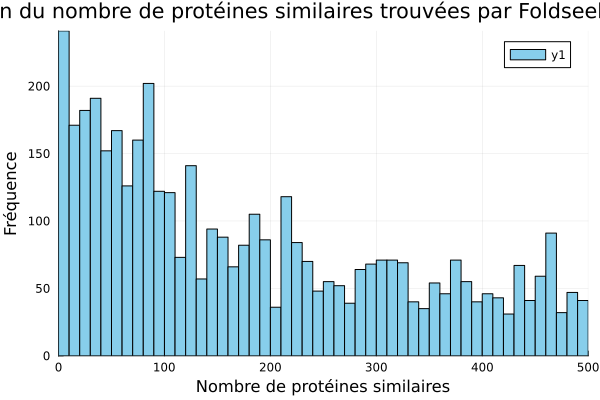

In [9]:
using Plots
histogram(df.NB_SIMILAR_PROT,
    title = "Répartition du nombre de protéines similaires trouvées par Foldseek (Cutoff 1e-5)",
    xlabel = "Nombre de protéines similaires",
    ylabel = "Fréquence",
    bins = 0:10:500,          # intervalles de 0 à 100 avec un pas de 5
    xlims = (0, 500),
    color = :skyblue,
    edgecolor = :black
)
